In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import pickle

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [3]:
customer_df = pd.read_csv("data/olist_customers_dataset.csv")
orders_df = pd.read_csv("data/olist_orders_dataset.csv")
reviews_df = pd.read_csv("data/olist_order_reviews_dataset.csv")
order_payments_df = pd.read_csv("data/olist_order_payments_dataset.csv")

### cleaning

### duplicate ,datetime, null

### customers

In [4]:
print(customer_df.info())
print(customer_df.isnull().sum())
print(customer_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
0


### orders

In [5]:
print(orders_df.info())
print(orders_df.isnull().sum())
print(orders_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date

In [6]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

In [7]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [8]:
orders_df = orders_df.dropna()
print(orders_df.isnull().sum())

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


### reviews

In [9]:
print(reviews_df.info())
print(reviews_df.isnull().sum())
print(reviews_df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
0


In [10]:
reviews_df['review_creation_date'] = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp'] = pd.to_datetime(reviews_df['review_answer_timestamp'])
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [11]:
reviews_df['review_id'].duplicated().sum()


814

In [12]:
reviews_df[reviews_df['review_id'].duplicated(keep=False)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
200,28642ce6250b94cc72bc85960aec6c62,e239d280236cdd3c40cb2c033f681d1c,5,NaN,NaN,2018-03-25,2018-03-25 21:03:02
344,a0a641414ff718ca079b3967ef5c2495,169d7e0fd71d624d306f132acd791cbe,5,NaN,NaN,2018-03-04,2018-03-06 20:12:53
346,f4d74b17cd63ee35efa82cd2567de911,f269e83a82f64baa3de97c2ebf3358f6,3,NaN,"A embalagem deixou a desejar, por pouco o prod...",2018-01-12,2018-01-13 18:46:10
360,ecbaf1fce7d2c09bfab46f89065afeaf,2451b9756f310d4cff5c7987b393870d,5,NaN,NaN,2017-07-27,2017-07-28 16:57:18
393,6b1de94de0f4bd84dfc4136818242faa,92acf87839903a94aeca0e5040d99acb,5,NaN,NaN,2018-02-16,2018-02-19 19:04:21
...,...,...,...,...,...,...,...
99108,2c6c08892b83ba4c1be33037c2842294,42ae1967f68c90bb325783ac55d761ce,4,NaN,"Chegou um pouco amassada, mas nada de mais, e ...",2017-07-03,2017-07-05 19:06:59
99124,6ec93e77f444e0b1703740a69122e35d,e1fdc6e9d1ca132377e862593a7c0bd4,5,NaN,Vendedor compromisso do vou o cliente,2017-10-07,2017-10-07 19:47:11
99164,2afe63a67dfd99b3038f568fb47ee761,c5334d330e36d2a810a7a13c72e135ee,5,NaN,"Muito bom, produto conforme anunciado, entrega...",2018-03-03,2018-03-04 22:56:47
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30


In [13]:
reviews_df = reviews_df.drop_duplicates(subset=['review_id'])

In [14]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98410 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                98410 non-null  object        
 1   order_id                 98410 non-null  object        
 2   review_score             98410 non-null  int64         
 3   review_comment_title     11519 non-null  object        
 4   review_comment_message   40668 non-null  object        
 5   review_creation_date     98410 non-null  datetime64[ns]
 6   review_answer_timestamp  98410 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 6.0+ MB


### payments

In [15]:
print(order_payments_df.info())
print(order_payments_df.isnull().sum())
print(order_payments_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
None
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
0


### tables creation

In [16]:
!pip install mysql

Defaulting to user installation because normal site-packages is not writeable


In [17]:
import mysql.connector
from datetime import date

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='25Mysql@',
    database='finalproj'
)
cursor = conn.cursor()

In [18]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS customers(
    customer_id VARCHAR(50) PRIMARY KEY,
    customer_unique_id VARCHAR(50),
    customer_zip_code_prefix INT,
    customer_city VARCHAR(100),
    customer_state VARCHAR(50)
)
""")


In [19]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS orders(
    order_id VARCHAR(50) NOT NULL PRIMARY KEY,
    customer_id VARCHAR(50),
    order_status VARCHAR(50),
    order_purchase_timestamp DATETIME,
    order_approved_at DATETIME,
    order_delivered_carrier_date DATETIME,
    order_delivered_customer_date DATETIME,
    order_estimated_delivery_date DATETIME,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
)
""")

In [20]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS order_reviews(
     review_id VARCHAR(50) NOT NULL PRIMARY KEY,
    order_id VARCHAR(50) NOT NULL,
    review_score INT,
    review_comment_title VARCHAR(255),
    review_comment_message TEXT,
    review_creation_date DATETIME,
    review_answer_timestamp DATETIME,
    FOREIGN KEY (order_id) REFERENCES orders(order_id)
)
""")
 

In [21]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS order_payments(
    order_id VARCHAR(50),
    payment_sequential INT,
    payment_type VARCHAR(50),
    payment_installments INT,
    payment_value DECIMAL(10,2),
    PRIMARY KEY (order_id, payment_sequential),
    FOREIGN KEY (order_id) REFERENCES orders(order_id)
)
""")

In [22]:
conn.commit()

### insertion

In [22]:
reviews_df['order_id'] = reviews_df['order_id'].astype(str).str.strip()

In [23]:
for _, row in customer_df.iterrows():
    cursor.execute("""
        INSERT INTO customers (customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state)
        VALUES (%s, %s, %s, %s, %s)
    """, (
        row['customer_id'],
        row['customer_unique_id'],
        row['customer_zip_code_prefix'],
        row['customer_city'],
        row['customer_state']
    ))

In [24]:
conn.commit()

In [25]:
for _, row in orders_df.iterrows():
    cursor.execute("""
        INSERT INTO orders (order_id, customer_id, order_status, order_purchase_timestamp,
                            order_approved_at, order_delivered_carrier_date,
                            order_delivered_customer_date, order_estimated_delivery_date)
        VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
    """, (
        row['order_id'],
        row['customer_id'],
        row['order_status'],
        row['order_purchase_timestamp'],
        row['order_approved_at'],
        row['order_delivered_carrier_date'],
        row['order_delivered_customer_date'],
        row['order_estimated_delivery_date']
    ))
conn.commit()

In [26]:
cursor.execute("SELECT order_id FROM orders")
existing_orders = {row[0] for row in cursor.fetchall()}

reviews_df = reviews_df[reviews_df['order_id'].isin(existing_orders)]

In [27]:
reviews_df = reviews_df[reviews_df['order_id'] != '7bc2406110b926393aa56f80a40eba40']

In [28]:
cursor.execute("SELECT review_id FROM order_reviews")
existing_ids = {row[0] for row in cursor.fetchall()}

for _, row in reviews_df.iterrows():
    if row['review_id'] not in existing_ids:
        cursor.execute("""
            INSERT INTO order_reviews (review_id, order_id, review_score, review_comment_title,
                                       review_comment_message, review_creation_date, review_answer_timestamp)
            VALUES (%s,%s,%s,%s,%s,%s,%s)
        """, (
            row['review_id'],
            row['order_id'],
            row['review_score'],
            row['review_comment_title'],
            row['review_comment_message'],
            row['review_creation_date'],
            row['review_answer_timestamp']
        ))
conn.commit()

In [29]:
cursor.execute("SELECT order_id FROM orders")
existing_orders = {row[0] for row in cursor.fetchall()}

for _, row in order_payments_df.iterrows():
    if row['order_id'] in existing_orders:
        cursor.execute("""
            INSERT INTO order_payments (order_id, payment_sequential, payment_type,
                                        payment_installments, payment_value)
            VALUES (%s,%s,%s,%s,%s)
        """, (
            row['order_id'],
            row['payment_sequential'],
            row['payment_type'],
            row['payment_installments'],
            row['payment_value']
        ))
conn.commit()

In [30]:
cursor.close()
conn.close()

### merging dataframes

In [19]:
orders_payments = orders_df.merge(order_payments_df, on="order_id", how="left")
orders_payments.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,credit_card,1.0,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,credit_card,1.0,28.62
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,1.0,credit_card,6.0,175.26
8,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,1.0,credit_card,3.0,75.16
9,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,1.0,boleto,1.0,35.95


In [20]:
df=orders_payments.merge(customer_df,on="customer_id",how="left")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [21]:
df=df.merge(reviews_df,on="order_id",how="left")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58


In [22]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,review_score,review_creation_date,review_answer_timestamp
count,101003,101003,101003,101003,101003,101002.000000,101002.000000,101002.000000,101003.000000,99847.000000,99847,99847
mean,2017-12-31 10:44:25.739027968,2017-12-31 20:54:47.742165760,2018-01-03 16:14:22.845133312,2018-01-13 00:29:51.021613568,2018-01-24 05:11:52.315475712,1.089068,2.853934,152.986185,35121.043721,4.155979,2018-01-13 04:12:38.348272896,2018-01-16 07:57:20.162979840
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,0.000000,0.000000,1003.000000,1.000000,2016-10-06 00:00:00,2016-10-07 18:32:28
25%,2017-09-12 08:38:00,2017-09-12 14:28:37,2017-09-14 18:23:41,2017-09-22 16:08:53,2017-10-03 00:00:00,1.000000,1.000000,56.780000,11370.000000,4.000000,2017-09-23 00:00:00,2017-09-27 06:57:10
50%,2018-01-18 20:46:23,2018-01-19 09:12:38,2018-01-23 16:46:55,2018-02-01 14:43:42,2018-02-15 00:00:00,1.000000,1.000000,100.000000,24416.000000,5.000000,2018-02-02 00:00:00,2018-02-05 00:16:10
75%,2018-05-04 14:49:58.500000,2018-05-04 21:50:20,2018-05-08 08:12:30,2018-05-15 16:34:15,2018-05-25 00:00:00,1.000000,4.000000,171.185000,58701.000000,5.000000,2018-05-16 00:00:00,2018-05-20 13:58:52
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,26.000000,24.000000,13664.080000,99980.000000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,NaN,NaN,NaN,NaN,NaN,0.656093,2.686661,214.331019,29781.258545,1.284394,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101003 entries, 0 to 101002
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       101003 non-null  object        
 1   customer_id                    101003 non-null  object        
 2   order_status                   101003 non-null  object        
 3   order_purchase_timestamp       101003 non-null  datetime64[ns]
 4   order_approved_at              101003 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101003 non-null  datetime64[ns]
 6   order_delivered_customer_date  101003 non-null  datetime64[ns]
 7   order_estimated_delivery_date  101003 non-null  datetime64[ns]
 8   payment_sequential             101002 non-null  float64       
 9   payment_type                   101002 non-null  object        
 10  payment_installments           101002 non-null  float64       
 11  

In [24]:
df[df['payment_value']==0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
433,45ed6e85398a87c253db47c2d9f48216,8eab8f9b3c744b76b65f7a2c0c8f2d6c,delivered,2017-06-08 21:18:45,2017-06-08 21:30:18,2017-06-09 08:35:18,2017-06-22 17:44:53,2017-07-10,3.0,voucher,...,e4000306cf2f63714e6bb70dd20a6592,74595,goiania,GO,b59cf587845cad9af780a2f839ee6c30,1.0,NaN,Produto demorou a chegar e veio diferente do q...,2017-06-23,2017-06-27 16:19:05
32847,6ccb433e00daae1283ccc956189c82ae,843b211abe7b0264dd4a69eafc5bdf43,delivered,2017-10-26 23:51:35,2017-10-27 00:46:58,2017-10-27 19:53:03,2017-11-08 18:47:00,2017-11-22,4.0,voucher,...,677ad9cdca6c47c733f0cc6e23d7bb4c,25625,petropolis,RJ,8d0e1d286cc6f63e3a784779c9d1f7d8,4.0,NaN,NaN,2017-11-09,2018-02-14 13:57:57
87084,b23878b3e8eb4d25a158f57d96331b18,648121b599d98c420ef93f6135f8c80c,delivered,2017-05-27 19:20:24,2017-05-27 19:35:17,2017-05-29 04:49:37,2017-06-07 08:53:10,2017-06-29,4.0,voucher,...,9077449283dc1319d5e51fb3159b28e2,29230,anchieta,ES,f75bfd523e8001ea6c62f86c48fae8a9,5.0,NaN,NaN,2017-06-08,2017-06-10 19:28:35
98476,8bcbe01d44d147f901cd3192671144db,f2def7f64f36952f2f5a9791f0285f34,delivered,2018-01-24 23:24:14,2018-01-24 23:37:20,2018-01-30 22:43:30,2018-02-02 21:26:42,2018-02-21,4.0,voucher,...,cc5aa1b8337e394da54980226bb0f6d4,21040,rio de janeiro,RJ,3d42038fd2a7d35a88b93cb3e51796a3,4.0,NaN,NaN,2018-02-03,2018-02-11 17:34:29


In [25]:
df.drop(df[df['payment_value']==0].index,inplace=True)

In [26]:
df.drop(df[df['order_status']=='canceled'].index,inplace=True)

In [27]:
df.drop("order_status", axis=1, inplace=True)

In [28]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58


In [29]:
df['review_score'].unique()

array([ 4.,  5.,  1., nan,  2.,  3.])

In [30]:
df[df['review_score'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
18,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06,1.0,credit_card,10.0,...,6e26bbeaa107ec34112c64e1ee31c0f5,21381,rio de janeiro,RJ,NaN,NaN,NaN,NaN,NaT,NaT
61,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,2017-03-13 18:14:36,2017-03-13 18:14:36,2017-03-22 14:03:09,2017-04-06 13:37:16,2017-03-30,1.0,boleto,1.0,...,51838d41add414a0b1b989b7d251d9ee,13068,campinas,SP,NaN,NaN,NaN,NaN,NaT,NaT
83,b8801cccd8068de30112e4f49903d74a,f26a435864aebedff7f7c84f82ee229f,2017-07-30 03:06:35,2017-07-30 03:25:08,2017-07-31 16:42:54,2017-08-01 14:27:31,2017-08-16,1.0,credit_card,2.0,...,bb4d84a2b45b22ed710ac8c0dec63d1a,8552,poa,SP,NaN,NaN,NaN,NaN,NaT,NaT
177,ce9feeba53c652dd6569cca62e2bb287,f7398fc942c8fa80e5419ae52e49f7fb,2018-04-15 19:42:06,2018-04-15 19:55:20,2018-04-19 14:32:30,2018-04-20 23:12:11,2018-04-26,1.0,credit_card,1.0,...,d01cf8c6c7c836c5dd9320585928f42b,6414,barueri,SP,NaN,NaN,NaN,NaN,NaT,NaT
249,7e3e92dc3eaf5389f32da97228f7dd0e,62d50e9a714ac024c196d9548594e2aa,2017-07-02 20:47:24,2017-07-02 21:03:55,2017-07-03 11:42:08,2017-07-11 20:22:31,2017-07-25,1.0,credit_card,4.0,...,ba77e9b6506636dcbd03e463d4786f24,95059,caxias do sul,RS,NaN,NaN,NaN,NaN,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100608,2fcdb0c004a2a538d3dd724ea76916bd,cf826be53b1fe4a39bc33c7f5f827835,2017-11-22 11:39:00,2017-11-22 11:49:05,2017-11-23 22:58:51,2017-12-15 00:23:25,2017-12-18,1.0,credit_card,9.0,...,d92462d83762d5e5c112bccc344119e6,65940,grajau,MA,NaN,NaN,NaN,NaN,NaT,NaT
100695,2f2df159f26ddb73d55ee72372200d3e,86a7245fffe6a418ca1658a13ecc4531,2017-07-17 01:19:50,2017-07-17 01:30:09,2017-07-17 22:14:50,2017-07-26 09:44:00,2017-08-09,1.0,credit_card,8.0,...,1d532194f005426adcdf6d969640d56e,35240,conselheiro pena,MG,NaN,NaN,NaN,NaN,NaT,NaT
100755,129c72226e320a7bf5b89efce442afd5,46dbd6b44084696774eb0bc59352069a,2018-02-12 03:09:04,2018-02-12 03:48:19,2018-02-15 05:41:47,2018-02-28 17:07:46,2018-03-12,1.0,credit_card,2.0,...,ae8482b27b2119e2c3278f5ddf9c1024,4941,sao paulo,SP,NaN,NaN,NaN,NaN,NaT,NaT
100783,f0dd9af88d8ef5a8e4670fbbedaf19c4,30ddb50bd22ee927ebe308ea3da60735,2017-09-02 20:38:29,2017-09-05 04:24:12,2017-09-14 23:13:41,2017-09-15 14:59:50,2017-09-19,1.0,boleto,1.0,...,1d627d8a6e1e33ea8eeeb7a17d998660,11045,santos,SP,NaN,NaN,NaN,NaN,NaT,NaT


In [31]:
df.dropna(subset=['review_score'],inplace=True)

In [32]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_purchase_timestamp             0
order_approved_at                    0
order_delivered_carrier_date         0
order_delivered_customer_date        0
order_estimated_delivery_date        0
payment_sequential                   1
payment_type                         1
payment_installments                 1
payment_value                        1
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
review_id                            0
review_score                         0
review_comment_title             88251
review_comment_message           59319
review_creation_date                 0
review_answer_timestamp              0
dtype: int64

In [33]:
df[df['payment_sequential'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
31242,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,NaN,NaN,NaN,...,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,6916ca4502d6d3bfd39818759d55d536,1.0,NaN,nao recebi o produto e nem resposta da empresa,2016-10-06,2016-10-07 18:32:28


In [34]:
df.dropna(subset=['payment_sequential'], inplace=True)

In [35]:
df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='object')

In [36]:
df.to_csv('df.csv',index=False)

In [37]:
nec_cols = [
    'order_id',
    'customer_id',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'payment_type',
    'payment_value',
    'payment_installments',
    'customer_unique_id',
    'customer_city',
    'customer_state',
    'review_score'
]

df1 = df[nec_cols].copy()

In [38]:
df1.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,payment_installments,customer_unique_id,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,credit_card,18.12,1.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,voucher,2.00,1.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,voucher,18.59,1.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,boleto,141.46,1.0,af07308b275d755c9edb36a90c618231,barreiras,BA,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,credit_card,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,5.0


In [39]:
df1.isnull().sum()

order_id                         0
customer_id                      0
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
payment_type                     0
payment_value                    0
payment_installments             0
customer_unique_id               0
customer_city                    0
customer_state                   0
review_score                     0
dtype: int64

### feature engineering

In [40]:
df1['delay']=(df['order_delivered_customer_date']-df['order_estimated_delivery_date']).dt.days
df1.head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,payment_installments,customer_unique_id,customer_city,customer_state,review_score,delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,credit_card,18.12,1.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.0,-8
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,voucher,2.00,1.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.0,-8
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,voucher,18.59,1.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.0,-8
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,boleto,141.46,1.0,af07308b275d755c9edb36a90c618231,barreiras,BA,4.0,-6
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,credit_card,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,5.0,-18


In [41]:
df1["delivery_time"] = (df1["order_delivered_customer_date"] - df1["order_purchase_timestamp"]).dt.days


In [42]:
def mode_func(x):
    return x.mode()[0] if not x.mode().empty else None

features = df1.groupby("customer_unique_id").agg(
    num_orders=("order_id", "nunique"),
    first_purchase=("order_purchase_timestamp", "min"),
    last_purchase=("order_purchase_timestamp", "max"),
    total_spend=("payment_value", "sum"),
    avg_order_value=("payment_value", "mean"),
    avg_installments=("payment_installments", "mean"),
    payment_type=("payment_type", mode_func),
    avg_delay=("delay", "mean"),
     avg_delivery_time=("delivery_time", "mean"),
    customer_state=("customer_state", "first"),
    avg_review_score=("review_score", "mean")
).reset_index()

In [43]:
features['last_purchase'].max()

Timestamp('2018-08-29 15:00:37')

In [44]:
features["days_since_last_purchase"] = (pd.Timestamp("2018-08-31")-features["last_purchase"]).dt.days

In [45]:
features["customer_lifetime_days"] = (features["last_purchase"] - features["first_purchase"]).dt.days


In [46]:
features = features.drop(columns=["first_purchase", "last_purchase"])

In [47]:
features.head()

,customer_unique_id,num_orders,total_spend,avg_order_value,avg_installments,payment_type,avg_delay,avg_delivery_time,customer_state,avg_review_score,days_since_last_purchase,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,8.0,credit_card,-5.0,6.0,SP,5.0,112,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,credit_card,-5.0,3.0,SP,4.0,115,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,8.0,credit_card,-2.0,25.0,SC,3.0,538,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,credit_card,-12.0,20.0,PA,4.0,322,0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,6.0,credit_card,-8.0,13.0,SP,5.0,289,0


In [48]:
features["customer_lifetime_days"] = features["customer_lifetime_days"].replace(0, 1)

In [49]:
features.columns

Index(['customer_unique_id', 'num_orders', 'total_spend', 'avg_order_value',
       'avg_installments', 'payment_type', 'avg_delay', 'avg_delivery_time',
       'customer_state', 'avg_review_score', 'days_since_last_purchase',
       'customer_lifetime_days'],
      dtype='object')

In [50]:
features.drop(features[features["total_spend"]==0].index,inplace=True)

In [51]:
features.drop(columns=['customer_unique_id'],inplace=True)
features.head()

,num_orders,total_spend,avg_order_value,avg_installments,payment_type,avg_delay,avg_delivery_time,customer_state,avg_review_score,days_since_last_purchase,customer_lifetime_days
0,1,141.90,141.90,8.0,credit_card,-5.0,6.0,SP,5.0,112,1
1,1,27.19,27.19,1.0,credit_card,-5.0,3.0,SP,4.0,115,1
2,1,86.22,86.22,8.0,credit_card,-2.0,25.0,SC,3.0,538,1
3,1,43.62,43.62,4.0,credit_card,-12.0,20.0,PA,4.0,322,1
4,1,196.89,196.89,6.0,credit_card,-8.0,13.0,SP,5.0,289,1


In [52]:
features.describe()

,num_orders,total_spend,avg_order_value,avg_installments,avg_delay,avg_delivery_time,avg_review_score,days_since_last_purchase,customer_lifetime_days
count,92703.000000,92703.000000,92703.000000,92703.000000,92703.000000,92703.000000,92703.000000,92703.000000,92703.000000
mean,1.028532,164.594093,157.379887,2.897187,-11.884251,12.062521,4.154312,238.317476,3.597090
std,0.194072,224.829450,215.479943,2.674026,10.076126,9.472396,1.279482,152.543712,24.825486
min,1.000000,9.590000,1.856818,0.000000,-147.000000,0.000000,1.000000,1.000000,1.000000
25%,1.000000,62.940000,60.590000,1.000000,-17.000000,6.000000,4.000000,115.000000,1.000000
50%,1.000000,107.550000,103.500000,2.000000,-12.000000,10.000000,5.000000,219.000000,1.000000
75%,1.000000,181.620000,174.300000,4.000000,-7.000000,15.000000,5.000000,347.000000,1.000000
max,15.000000,13664.080000,13664.080000,24.000000,188.000000,208.000000,5.000000,696.000000,633.000000


In [53]:
features['cltv']= features['avg_order_value']*features['num_orders']*features['customer_lifetime_days']

### EDA

<Axes: xlabel='avg_review_score', ylabel='cltv'>

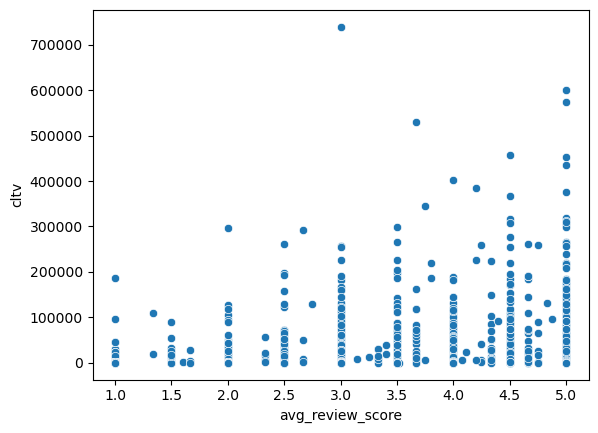

In [54]:
import seaborn as sns
sns.scatterplot(y="cltv", x="avg_review_score", data=features)


<Axes: xlabel='total_spend', ylabel='cltv'>

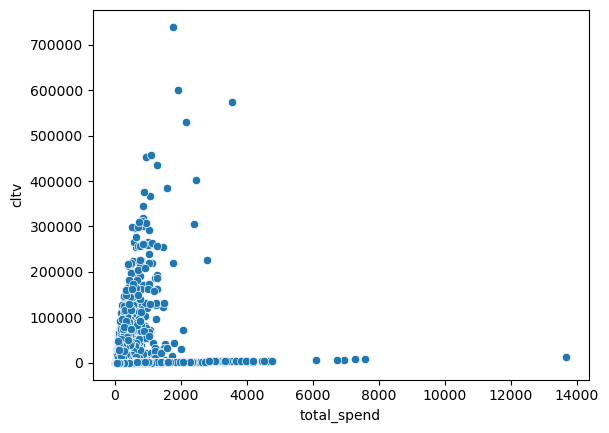

In [55]:
import seaborn as sns
sns.scatterplot(y="cltv", x="total_spend", data=features)


<Axes: xlabel='total_spend', ylabel='avg_order_value'>

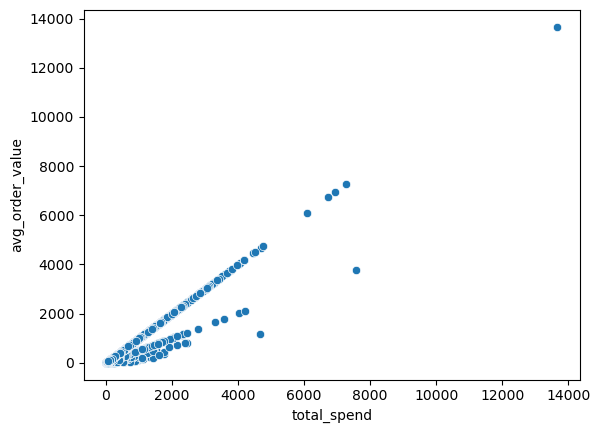

In [56]:
import seaborn as sns
sns.scatterplot(y="avg_order_value", x="total_spend", data=features)


<Axes: xlabel='total_spend', ylabel='cltv'>

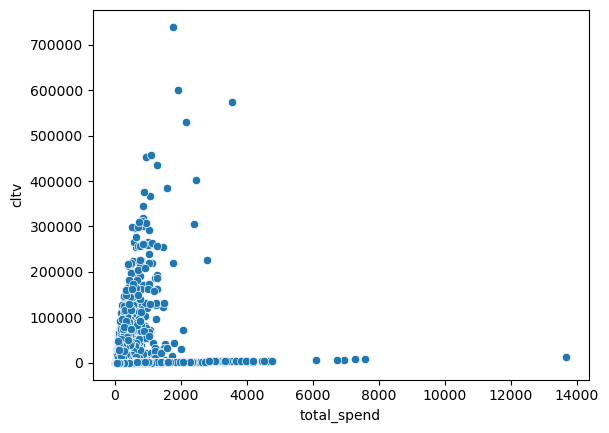

In [57]:
import seaborn as sns
sns.scatterplot(y="cltv", x="total_spend", data=features)


In [58]:
features[features['total_spend']>6000]

,num_orders,total_spend,avg_order_value,avg_installments,payment_type,avg_delay,avg_delivery_time,customer_state,avg_review_score,days_since_last_purchase,customer_lifetime_days,cltv
3702,1,13664.08,13664.080,1.0,credit_card,-6.0,18.0,RJ,1.0,335,1,13664.08
23245,1,6081.54,6081.540,1.0,boleto,-9.0,19.0,MG,1.0,279,1,6081.54
42873,1,7274.88,7274.880,1.0,boleto,-7.0,11.0,ES,1.0,46,1,7274.88
79075,2,7571.63,3785.815,10.0,credit_card,-18.5,15.0,RJ,5.0,516,1,7571.63
79893,1,6929.31,6929.310,8.0,credit_card,-6.0,18.0,MS,5.0,564,1,6929.31
92429,1,6726.66,6726.660,1.0,boleto,-23.0,11.0,SP,5.0,463,1,6726.66


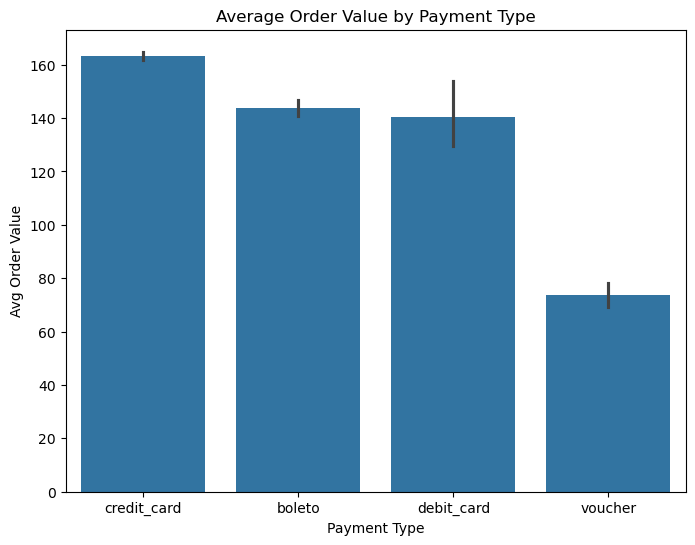

In [59]:
plt.figure(figsize=(8,6))
sns.barplot(data=features, x="payment_type", y="avg_order_value", estimator="mean")
plt.title("Average Order Value by Payment Type")
plt.ylabel("Avg Order Value")
plt.xlabel("Payment Type")
plt.show()


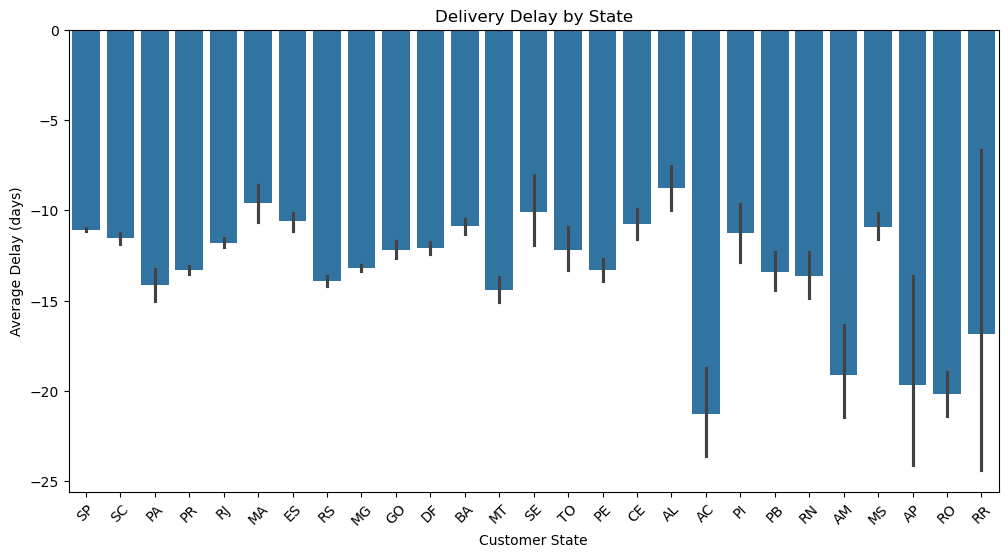

In [60]:
plt.figure(figsize=(12,6))
sns.barplot(data=features, x="customer_state", y="avg_delay")
plt.title("Delivery Delay by State")
plt.ylabel("Average Delay (days)")
plt.xlabel("Customer State")
plt.xticks(rotation=45)
plt.show()

### numerical

In [61]:
cltv=features.copy()
cltv.head()

,num_orders,total_spend,avg_order_value,avg_installments,payment_type,avg_delay,avg_delivery_time,customer_state,avg_review_score,days_since_last_purchase,customer_lifetime_days,cltv
0,1,141.90,141.90,8.0,credit_card,-5.0,6.0,SP,5.0,112,1,141.90
1,1,27.19,27.19,1.0,credit_card,-5.0,3.0,SP,4.0,115,1,27.19
2,1,86.22,86.22,8.0,credit_card,-2.0,25.0,SC,3.0,538,1,86.22
3,1,43.62,43.62,4.0,credit_card,-12.0,20.0,PA,4.0,322,1,43.62
4,1,196.89,196.89,6.0,credit_card,-8.0,13.0,SP,5.0,289,1,196.89


In [62]:
cltv.shape

(92703, 12)

In [63]:
cltv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92703 entries, 0 to 92702
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   num_orders                92703 non-null  int64  
 1   total_spend               92703 non-null  float64
 2   avg_order_value           92703 non-null  float64
 3   avg_installments          92703 non-null  float64
 4   payment_type              92703 non-null  object 
 5   avg_delay                 92703 non-null  float64
 6   avg_delivery_time         92703 non-null  float64
 7   customer_state            92703 non-null  object 
 8   avg_review_score          92703 non-null  float64
 9   days_since_last_purchase  92703 non-null  int64  
 10  customer_lifetime_days    92703 non-null  int64  
 11  cltv                      92703 non-null  float64
dtypes: float64(7), int64(3), object(2)
memory usage: 8.5+ MB


In [64]:
numeric_features = cltv.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_features

['num_orders',
 'total_spend',
 'avg_order_value',
 'avg_installments',
 'avg_delay',
 'avg_delivery_time',
 'avg_review_score',
 'days_since_last_purchase',
 'customer_lifetime_days',
 'cltv']

### outliers removal usinf IQR

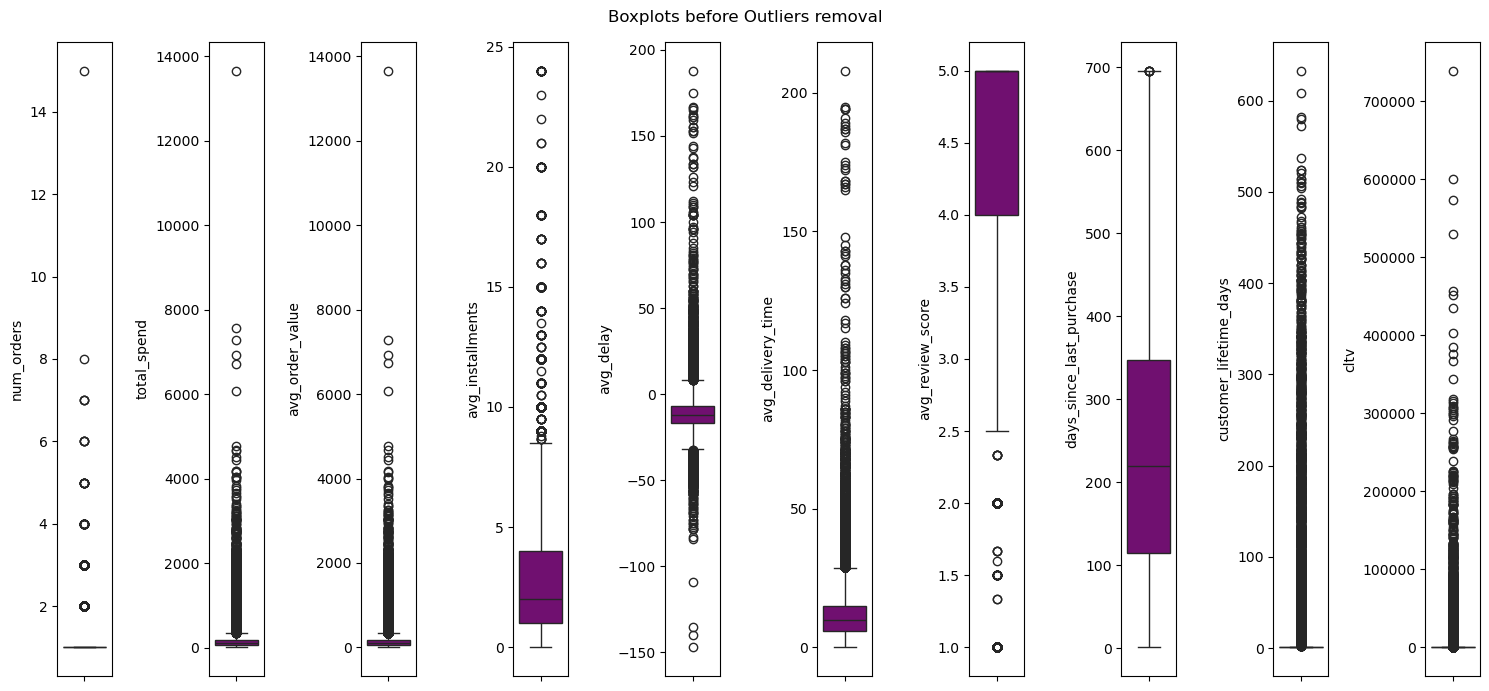

In [65]:
plt.figure(figsize=(15, 7))
plt.suptitle("Boxplots before Outliers removal")
for i in range(0, len(numeric_features)):
    plt.subplot(1, 10, i+1)
    sns.boxplot(y=cltv[numeric_features[i]],color='purple')
    plt.tight_layout()

In [66]:
for col in numeric_features:
    Q1 = cltv[col].quantile(0.25)
    Q3 = cltv[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 2.5 * IQR
    print(col)
    print(lower,upper)


num_orders
1.0 1.0
total_spend
-115.08000000000001 478.32000000000005
avg_order_value
-109.975 458.57500000000005
avg_installments
-3.5 11.5
avg_delay
-32.0 18.0
avg_delivery_time
-7.5 37.5
avg_review_score
2.5 7.5
days_since_last_purchase
-233.0 927.0
customer_lifetime_days
1.0 1.0
cltv
-120.51749999999996 485.65749999999997


In [67]:
num =['total_spend','avg_order_value','avg_installments','days_since_last_purchase','avg_delivery_time','avg_delay']

In [68]:
Q1 = cltv[num].quantile(0.25)
Q3 = cltv[num].quantile(0.75)
IQR = Q3 - Q1

cltv= cltv[~(
    (cltv[num] < (Q1 - 1.5 * IQR)) |
    (cltv[num] > (Q3 + 2.5 * IQR))
).any(axis=1)]

print(cltv.shape)


(84412, 12)


In [69]:
numeric_features = cltv.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_features

['num_orders',
 'total_spend',
 'avg_order_value',
 'avg_installments',
 'avg_delay',
 'avg_delivery_time',
 'avg_review_score',
 'days_since_last_purchase',
 'customer_lifetime_days',
 'cltv']

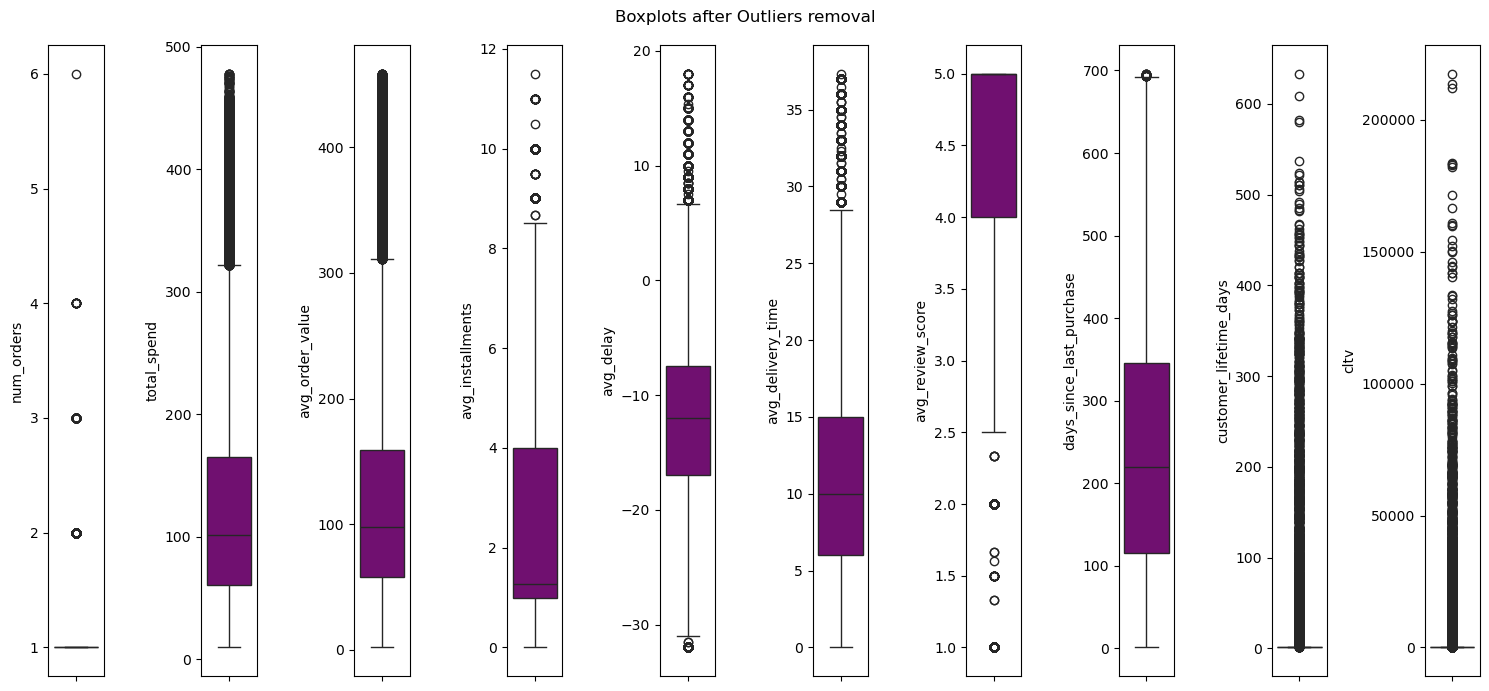

In [70]:
plt.figure(figsize=(15, 7))
plt.suptitle("Boxplots after Outliers removal")
for i in range(0, len(numeric_features)):
    plt.subplot(1, 10, i+1)
    sns.boxplot(y=cltv[numeric_features[i]],color='purple')
    plt.tight_layout()

<Axes: >

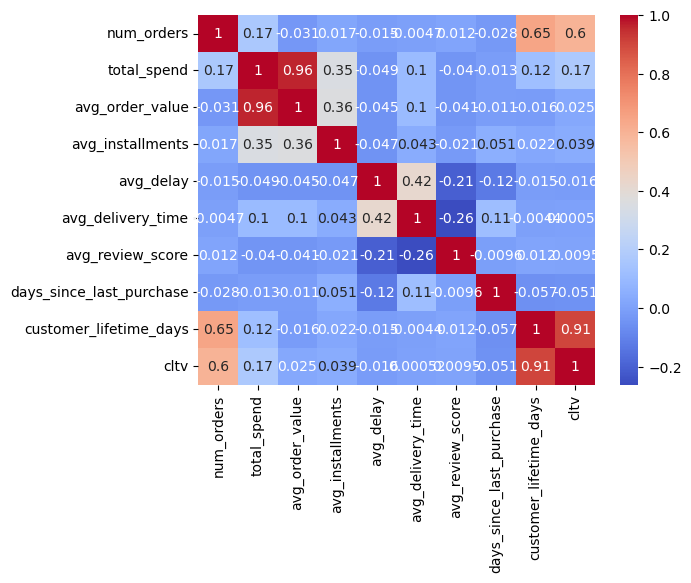

In [71]:
sns.heatmap(cltv[numeric_features].corr(), annot=True, cmap="coolwarm")

In [72]:
cltv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84412 entries, 0 to 92702
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   num_orders                84412 non-null  int64  
 1   total_spend               84412 non-null  float64
 2   avg_order_value           84412 non-null  float64
 3   avg_installments          84412 non-null  float64
 4   payment_type              84412 non-null  object 
 5   avg_delay                 84412 non-null  float64
 6   avg_delivery_time         84412 non-null  float64
 7   customer_state            84412 non-null  object 
 8   avg_review_score          84412 non-null  float64
 9   days_since_last_purchase  84412 non-null  int64  
 10  customer_lifetime_days    84412 non-null  int64  
 11  cltv                      84412 non-null  float64
dtypes: float64(7), int64(3), object(2)
memory usage: 8.4+ MB


In [73]:
cltv[cltv['num_orders']>1]

,num_orders,total_spend,avg_order_value,avg_installments,payment_type,avg_delay,avg_delivery_time,customer_state,avg_review_score,days_since_last_purchase,customer_lifetime_days,cltv
104,2,354.37,177.185000,2.0,credit_card,-17.500000,6.500000,RJ,5.000000,228,170,60242.90
243,2,123.25,61.625000,1.0,credit_card,-19.000000,17.500000,DF,4.000000,88,10,1232.50
304,2,126.20,63.100000,1.0,boleto,-12.500000,5.500000,SP,4.000000,527,1,126.20
402,2,214.90,107.450000,1.5,credit_card,-10.000000,13.000000,MG,3.500000,134,60,12894.00
417,2,236.30,118.150000,8.0,credit_card,-16.000000,12.500000,BA,4.500000,196,176,41588.80
...,...,...,...,...,...,...,...,...,...,...,...,...
92097,3,185.09,61.696667,2.0,credit_card,-17.666667,11.000000,DF,3.333333,373,75,13881.75
92111,2,196.20,98.100000,3.0,credit_card,-8.500000,8.500000,SP,5.000000,283,1,196.20
92272,2,286.14,143.070000,10.0,credit_card,-7.000000,21.500000,RJ,5.000000,165,88,25180.32
92552,3,139.60,46.533333,2.0,credit_card,-8.333333,16.666667,SP,4.333333,350,204,28478.40


In [74]:
cltv.drop(columns=['total_spend','num_orders'],inplace=True)

### skeness

In [75]:
numeric_features = cltv.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_features

['avg_order_value',
 'avg_installments',
 'avg_delay',
 'avg_delivery_time',
 'avg_review_score',
 'days_since_last_purchase',
 'customer_lifetime_days',
 'cltv']

In [76]:
skewness = cltv[numeric_features].skew()
skewness

avg_order_value              1.415179
avg_installments             1.574715
avg_delay                    0.225043
avg_delivery_time            1.118254
avg_review_score            -1.579165
days_since_last_purchase     0.398230
customer_lifetime_days      13.055596
cltv                        16.535021
dtype: float64

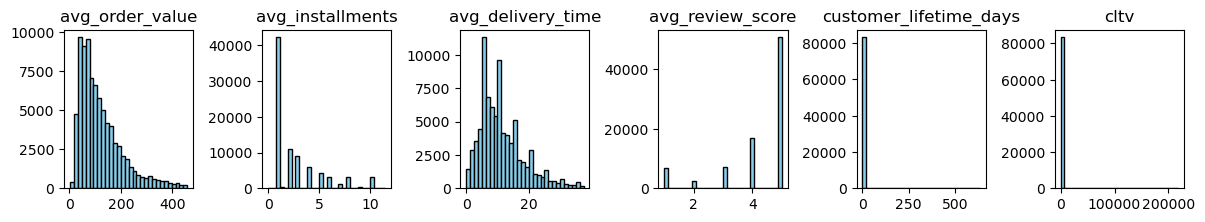

In [77]:
skewed_cols = skewness[abs(skewness) > 0.5].index

plt.figure(figsize=(16, 8))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(4, 8, i)
    plt.hist(cltv[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

### categorical

In [78]:
categorical_features=cltv.select_dtypes(include=["object"])
print(categorical_features.head())

  payment_type customer_state
0  credit_card             SP
1  credit_card             SP
2  credit_card             SC
3  credit_card             PA
4  credit_card             SP


In [79]:
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(cltv[col].value_counts())
    print(cltv[col].nunique())


Column: payment_type
payment_type
credit_card    64323
boleto         17135
voucher         1630
debit_card      1324
Name: count, dtype: int64
4

Column: customer_state
customer_state
SP    36680
RJ    10150
MG    10138
RS     4634
PR     4377
SC     3113
BA     2737
DF     1853
ES     1760
GO     1705
PE     1299
CE     1013
MT      727
PA      696
MS      619
MA      582
PB      391
PI      376
RN      375
AL      292
SE      263
TO      233
RO      189
AM       91
AC       55
AP       45
RR       19
Name: count, dtype: int64
27


### encoding

In [80]:
df_1= pd.get_dummies(cltv, columns=['payment_type','customer_state'],dtype=int)
df_1.head()

,avg_order_value,avg_installments,avg_delay,avg_delivery_time,avg_review_score,days_since_last_purchase,customer_lifetime_days,cltv,payment_type_boleto,payment_type_credit_card,...,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO
0,141.90,8.0,-5.0,6.0,5.0,112,1,141.90,0,1,...,0,0,0,0,0,0,0,0,1,0
1,27.19,1.0,-5.0,3.0,4.0,115,1,27.19,0,1,...,0,0,0,0,0,0,0,0,1,0
2,86.22,8.0,-2.0,25.0,3.0,538,1,86.22,0,1,...,0,0,0,0,0,0,1,0,0,0
3,43.62,4.0,-12.0,20.0,4.0,322,1,43.62,0,1,...,0,0,0,0,0,0,0,0,0,0
4,196.89,6.0,-8.0,13.0,5.0,289,1,196.89,0,1,...,0,0,0,0,0,0,0,0,1,0


In [81]:
df_1.columns

Index(['avg_order_value', 'avg_installments', 'avg_delay', 'avg_delivery_time',
       'avg_review_score', 'days_since_last_purchase',
       'customer_lifetime_days', 'cltv', 'payment_type_boleto',
       'payment_type_credit_card', 'payment_type_debit_card',
       'payment_type_voucher', 'customer_state_AC', 'customer_state_AL',
       'customer_state_AM', 'customer_state_AP', 'customer_state_BA',
       'customer_state_CE', 'customer_state_DF', 'customer_state_ES',
       'customer_state_GO', 'customer_state_MA', 'customer_state_MG',
       'customer_state_MS', 'customer_state_MT', 'customer_state_PA',
       'customer_state_PB', 'customer_state_PE', 'customer_state_PI',
       'customer_state_PR', 'customer_state_RJ', 'customer_state_RN',
       'customer_state_RO', 'customer_state_RR', 'customer_state_RS',
       'customer_state_SC', 'customer_state_SE', 'customer_state_SP',
       'customer_state_TO'],
      dtype='object')

In [82]:
df_fin = df_1.sample(frac=0.5, random_state=42)

df_fin = df_fin.reset_index(drop=True)

print(df_fin.shape)


(42206, 39)


### feature importance

In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

X = df_fin.drop(columns=["cltv"])
y = df_fin["cltv"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance)

                     feature    importance
6     customer_lifetime_days  8.450890e-01
0            avg_order_value  1.387960e-01
3          avg_delivery_time  4.036311e-03
2                  avg_delay  3.983646e-03
5   days_since_last_purchase  2.782724e-03
1           avg_installments  2.072101e-03
4           avg_review_score  7.142765e-04
29         customer_state_RJ  5.786228e-04
15         customer_state_BA  4.049371e-04
36         customer_state_SP  2.942442e-04
7        payment_type_boleto  2.623574e-04
8   payment_type_credit_card  1.761224e-04
21         customer_state_MG  1.702842e-04
28         customer_state_PR  1.341939e-04
18         customer_state_ES  1.308014e-04
24         customer_state_PA  9.585483e-05
31         customer_state_RO  8.190030e-05
33         customer_state_RS  7.764923e-05
34         customer_state_SC  3.535023e-05
23         customer_state_MT  2.981285e-05
10      payment_type_voucher  2.003846e-05
19         customer_state_GO  8.622075e-06
26         

In [84]:
df_fin.drop(columns=['customer_state_AC',
       'customer_state_AL', 'customer_state_AM', 'customer_state_AP',
       'customer_state_BA', 'customer_state_CE', 'customer_state_DF',
       'customer_state_ES', 'customer_state_GO', 'customer_state_MA',
       'customer_state_MG', 'customer_state_MS', 'customer_state_MT',
       'customer_state_PA', 'customer_state_PB', 'customer_state_PE',
       'customer_state_PI', 'customer_state_PR', 'customer_state_RJ',
       'customer_state_RN', 'customer_state_RO', 'customer_state_RR',
       'customer_state_RS', 'customer_state_SC', 'customer_state_SE',
       'customer_state_SP', 'customer_state_TO'],inplace=True)
df_fin.head()

,avg_order_value,avg_installments,avg_delay,avg_delivery_time,avg_review_score,days_since_last_purchase,customer_lifetime_days,cltv,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher
0,112.02,1.0,-14.0,7.0,5.0,408,1,112.02,0,1,0,0
1,118.66,2.0,-5.0,25.0,5.0,137,1,118.66,0,1,0,0
2,27.53,1.0,-15.0,5.0,5.0,106,1,27.53,0,1,0,0
3,443.35,4.0,-19.0,8.0,4.0,280,1,443.35,0,1,0,0
4,76.66,1.0,-17.0,13.0,5.0,258,1,76.66,0,1,0,0


In [85]:
df2=df_fin.copy()

In [86]:
df2.head()

,avg_order_value,avg_installments,avg_delay,avg_delivery_time,avg_review_score,days_since_last_purchase,customer_lifetime_days,cltv,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher
0,112.02,1.0,-14.0,7.0,5.0,408,1,112.02,0,1,0,0
1,118.66,2.0,-5.0,25.0,5.0,137,1,118.66,0,1,0,0
2,27.53,1.0,-15.0,5.0,5.0,106,1,27.53,0,1,0,0
3,443.35,4.0,-19.0,8.0,4.0,280,1,443.35,0,1,0,0
4,76.66,1.0,-17.0,13.0,5.0,258,1,76.66,0,1,0,0


### models

In [84]:
X = df2.drop('cltv', axis=1)
y = df2['cltv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_col = ['days_since_last_purchase']
scaler = StandardScaler()

X_train[n_col] = scaler.fit_transform(X_train[n_col])
X_test[n_col] = scaler.transform(X_test[n_col])

joblib.dump(scaler, "scaler.pkl")

models = {
    "XGBRegressor": XGBRegressor(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R²:", r2_score(y_test, y_pred))


XGBRegressor
MAE: 70.8702759519816
MSE: 801393.5426836561
RMSE: 895.2058660909546
R²: 0.9801355859563924
DecisionTree
MAE: 96.61158165253853
MSE: 1910338.9957758207
RMSE: 1382.150135034476
R²: 0.9526477782081155
RandomForest
MAE: 61.30522491652333
MSE: 694288.9462585966
RMSE: 833.2400291984277
R²: 0.9827904239804626
GradientBoosting
MAE: 74.6647745627411
MSE: 850937.5677110632
RMSE: 922.4627730759996
R²: 0.978907521373746


In [85]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
joblib.dump(model, "rfr_final.pkl")

['rfr_final.pkl']

### churn

In [87]:
df_fin["churn_flag"] = (df_fin["days_since_last_purchase"] >150).astype(int)

df_fin.head()

,avg_order_value,avg_installments,avg_delay,avg_delivery_time,avg_review_score,days_since_last_purchase,customer_lifetime_days,cltv,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,churn_flag
0,112.02,1.0,-14.0,7.0,5.0,408,1,112.02,0,1,0,0,1
1,118.66,2.0,-5.0,25.0,5.0,137,1,118.66,0,1,0,0,0
2,27.53,1.0,-15.0,5.0,5.0,106,1,27.53,0,1,0,0,0
3,443.35,4.0,-19.0,8.0,4.0,280,1,443.35,0,1,0,0,1
4,76.66,1.0,-17.0,13.0,5.0,258,1,76.66,0,1,0,0,1


In [88]:
df_fin.drop(columns=["days_since_last_purchase"],inplace=True)

In [89]:
df_fin.head()

,avg_order_value,avg_installments,avg_delay,avg_delivery_time,avg_review_score,customer_lifetime_days,cltv,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,churn_flag
0,112.02,1.0,-14.0,7.0,5.0,1,112.02,0,1,0,0,1
1,118.66,2.0,-5.0,25.0,5.0,1,118.66,0,1,0,0,0
2,27.53,1.0,-15.0,5.0,5.0,1,27.53,0,1,0,0,0
3,443.35,4.0,-19.0,8.0,4.0,1,443.35,0,1,0,0,1
4,76.66,1.0,-17.0,13.0,5.0,1,76.66,0,1,0,0,1


In [90]:
numeric_cols = df_fin.select_dtypes(include=['float64', 'int64']).columns.tolist()
skewness = df_fin[numeric_cols].skew()

print("Skewness of numerical columns:")
print(skewness)
skewed_cols = skewness[abs(skewness) > 0.5].index.tolist()

print("\nColumns with absolute skewness > 0.5:")
print(skewed_cols)

Skewness of numerical columns:
avg_order_value            1.403147
avg_installments           1.585917
avg_delay                  0.229491
avg_delivery_time          1.115927
avg_review_score          -1.579500
customer_lifetime_days    12.650567
cltv                      15.487397
dtype: float64

Columns with absolute skewness > 0.5:
['avg_order_value', 'avg_installments', 'avg_delivery_time', 'avg_review_score', 'customer_lifetime_days', 'cltv']


In [91]:
n_col = ['avg_order_value','avg_installments', 'avg_delivery_time','avg_review_score', 'customer_lifetime_days','cltv']
for col in n_col:
    log_data = np.log1p(df_fin[col].clip(lower=0))
    sqrt_data = np.sqrt(df_fin[col].clip(lower=0))

    log_skew = log_data.skew()
    sqrt_skew = sqrt_data.skew()
    orig_skew = df_fin[col].skew()

    print(f"Column: {col}")
    print(f"Original skewness: {orig_skew:.4f}")
    print(f"Log transform skewness: {log_skew:.4f}")
    print(f"Sqrt transform skewness: {sqrt_skew:.4f}")
    print("-" * 50)

Column: avg_order_value
Original skewness: 1.4031
Log transform skewness: -0.0981
Sqrt transform skewness: 0.6598
--------------------------------------------------
Column: avg_installments
Original skewness: 1.5859
Log transform skewness: 0.8738
Sqrt transform skewness: 1.0905
--------------------------------------------------
Column: avg_delivery_time
Original skewness: 1.1159
Log transform skewness: -0.3354
Sqrt transform skewness: 0.3361
--------------------------------------------------
Column: avg_review_score
Original skewness: -1.5795
Log transform skewness: -2.0164
Sqrt transform skewness: -1.8818
--------------------------------------------------
Column: customer_lifetime_days
Original skewness: 12.6506
Log transform skewness: 7.8632
Sqrt transform skewness: 9.5381
--------------------------------------------------
Column: cltv
Original skewness: 15.4874
Log transform skewness: 2.6547
Sqrt transform skewness: 9.7963
--------------------------------------------------


In [92]:
df_fin[n_col] = df_fin[n_col].apply(lambda x: np.log1p(x))
skewness = df_fin[n_col].skew()
skewness

avg_order_value          -0.098088
avg_installments          0.873802
avg_delivery_time        -0.335375
avg_review_score         -2.016447
customer_lifetime_days    7.863172
cltv                      2.654738
dtype: float64

In [93]:
df_fin["churn_flag"].value_counts()

churn_flag
1    27881
0    14325
Name: count, dtype: int64

In [94]:
X = df_fin.drop(columns=["churn_flag"])
y = df_fin["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance)

                     feature  importance
0            avg_order_value    0.243954
6                       cltv    0.242148
2                  avg_delay    0.178424
3          avg_delivery_time    0.152472
1           avg_installments    0.079158
4           avg_review_score    0.060841
7        payment_type_boleto    0.014323
8   payment_type_credit_card    0.013760
9    payment_type_debit_card    0.005616
5     customer_lifetime_days    0.005163
10      payment_type_voucher    0.004141



=== Baseline Logistic Regression ===
              precision    recall  f1-score   support

           0     0.5815    0.1668    0.2593      2865
           1     0.6867    0.9383    0.7931      5577

    accuracy                         0.6765      8442
   macro avg     0.6341    0.5526    0.5262      8442
weighted avg     0.6510    0.6765    0.6119      8442



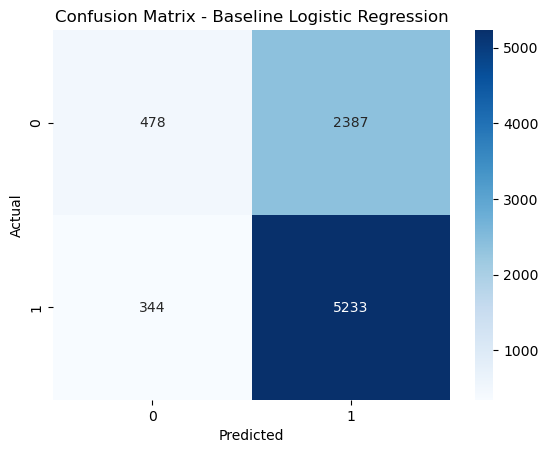

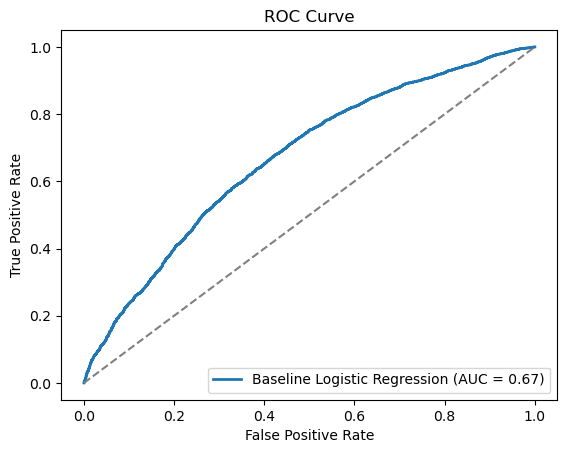

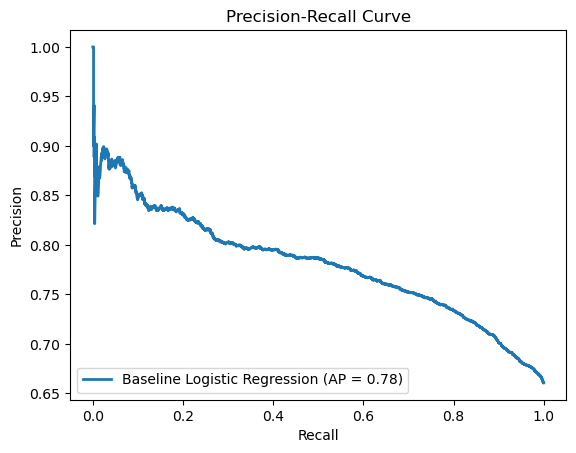

Accuracy: 0.6764984600805496
F1 Score: 0.7930590285670985
ROC-AUC: 0.6697109575885251

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.17      0.26      2865
           1       0.69      0.94      0.79      5577

    accuracy                           0.68      8442
   macro avg       0.63      0.55      0.53      8442
weighted avg       0.65      0.68      0.61      8442


=== Random Oversampling ===
              precision    recall  f1-score   support

           0     0.4741    0.5843    0.5235      2865
           1     0.7575    0.6670    0.7094      5577

    accuracy                         0.6389      8442
   macro avg     0.6158    0.6257    0.6164      8442
weighted avg     0.6613    0.6389    0.6463      8442



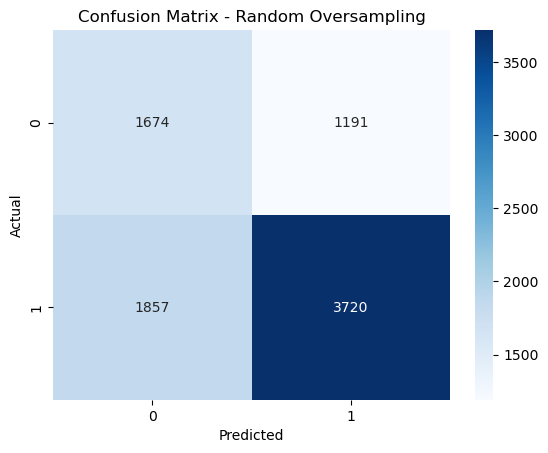

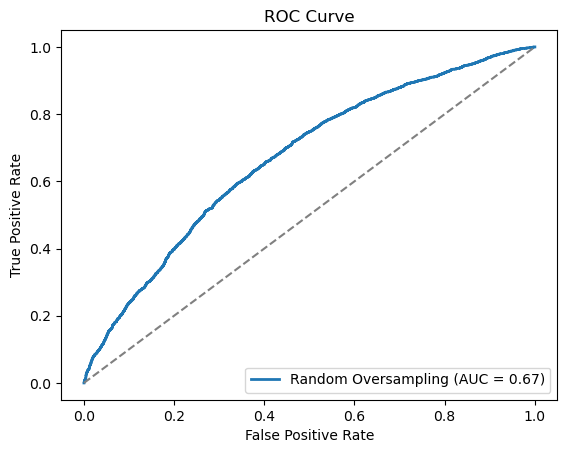

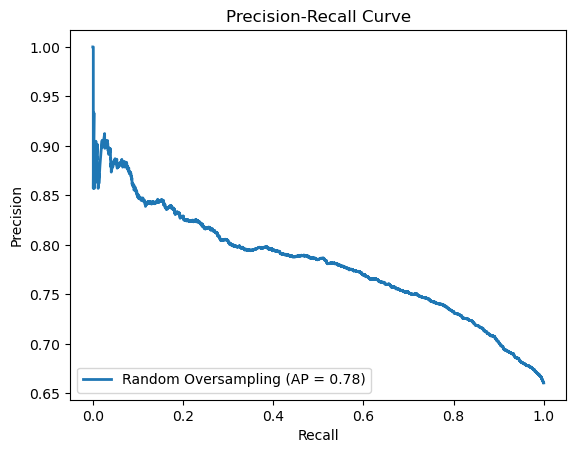

Accuracy: 0.6389481165600569
F1 Score: 0.7093821510297483
ROC-AUC: 0.66947544780811

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.58      0.52      2865
           1       0.76      0.67      0.71      5577

    accuracy                           0.64      8442
   macro avg       0.62      0.63      0.62      8442
weighted avg       0.66      0.64      0.65      8442


=== Random Undersampling ===
              precision    recall  f1-score   support

           0     0.4731    0.5839    0.5227      2865
           1     0.7570    0.6659    0.7086      5577

    accuracy                         0.6381      8442
   macro avg     0.6151    0.6249    0.6157      8442
weighted avg     0.6607    0.6381    0.6455      8442



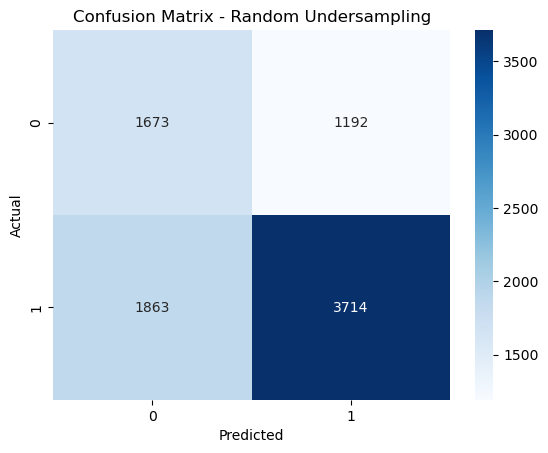

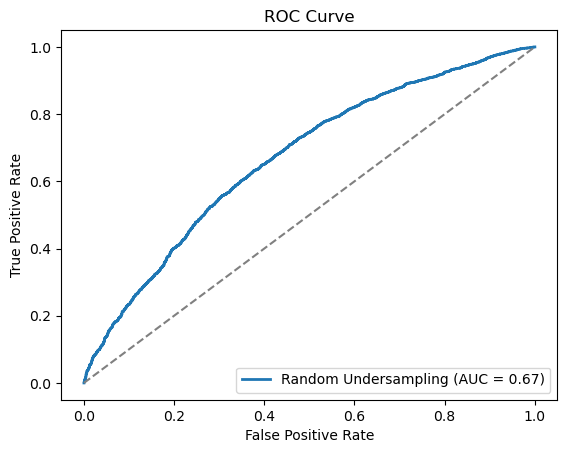

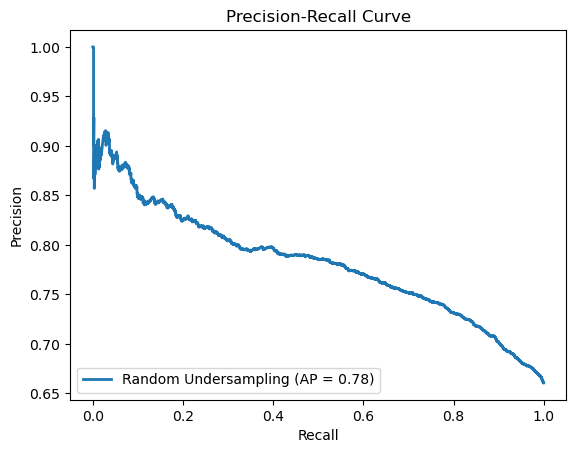

Accuracy: 0.6381189291637053
F1 Score: 0.708575789373271
ROC-AUC: 0.6694466584116203

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.58      0.52      2865
           1       0.76      0.67      0.71      5577

    accuracy                           0.64      8442
   macro avg       0.62      0.62      0.62      8442
weighted avg       0.66      0.64      0.65      8442


=== Class Weights ===
              precision    recall  f1-score   support

           0     0.4735    0.5853    0.5235      2865
           1     0.7576    0.6656    0.7086      5577

    accuracy                         0.6384      8442
   macro avg     0.6155    0.6255    0.6160      8442
weighted avg     0.6611    0.6384    0.6458      8442



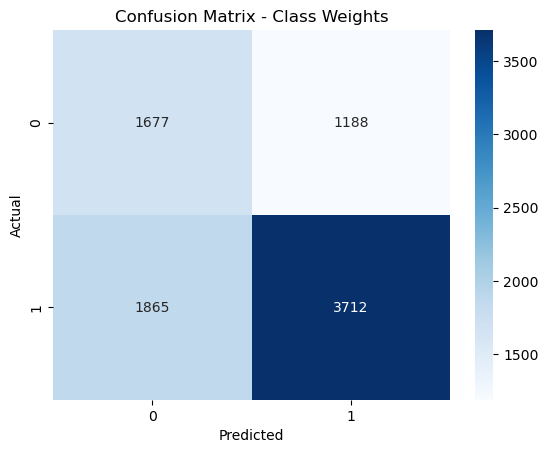

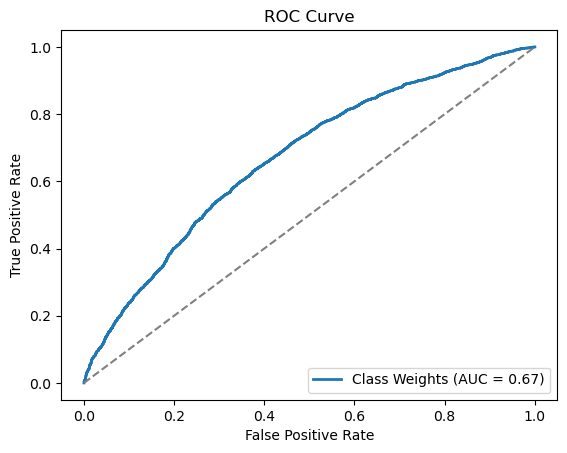

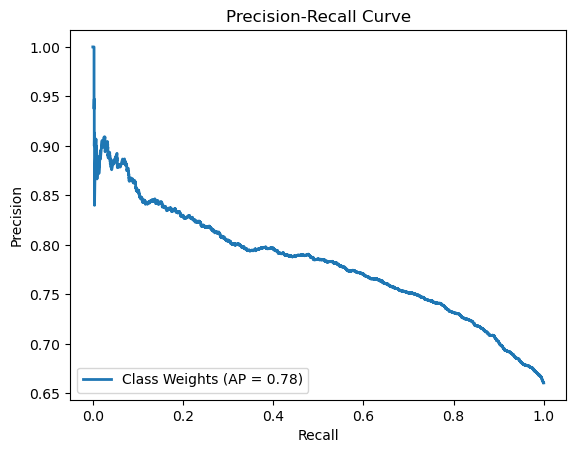

Accuracy: 0.6383558398483772
F1 Score: 0.708599790016226
ROC-AUC: 0.6694298854588827

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.59      0.52      2865
           1       0.76      0.67      0.71      5577

    accuracy                           0.64      8442
   macro avg       0.62      0.63      0.62      8442
weighted avg       0.66      0.64      0.65      8442



In [95]:
X = df_fin.drop(columns=["churn_flag"])
y = df_fin["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols_to_scale = [
    'avg_order_value', 'avg_installments', 'avg_delay', 'avg_delivery_time',
    'avg_review_score', 'customer_lifetime_days','cltv'
]

scaler = StandardScaler()
X_train[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

def evaluate_model(model, X_train, y_train, X_test, y_test, title):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n=== {title} ===")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix - {title}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{title} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, lw=2, label=f"{title} (AP = {ap:.2f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.show()

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
evaluate_model(LogisticRegression(max_iter=5000), X_train, y_train, X_test, y_test, "Baseline Logistic Regression")


ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
evaluate_model(LogisticRegression(max_iter=5000), X_res, y_res, X_test, y_test, "Random Oversampling")

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
evaluate_model(LogisticRegression(max_iter=5000), X_res, y_res, X_test, y_test, "Random Undersampling")

evaluate_model(LogisticRegression(max_iter=5000, class_weight="balanced"), X_train, y_train, X_test, y_test, "Class Weights")

In [97]:
X = df_fin.drop(columns=['churn_flag'])
y = df_fin['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols_to_scale = [
    'avg_order_value', 'avg_installments', 'avg_delay', 'avg_delivery_time',
    'avg_review_score', 'customer_lifetime_days','cltv'
]

scaler2 = StandardScaler()
X_train[numeric_cols_to_scale] = scaler2.fit_transform(X_train[numeric_cols_to_scale])
X_test[numeric_cols_to_scale] = scaler2.transform(X_test[numeric_cols_to_scale])

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6945036721156124
F1 Score: 0.7904785116581363
ROC-AUC: 0.6812062819714854

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.35      0.44      2865
           1       0.72      0.87      0.79      5577

    accuracy                           0.69      8442
   macro avg       0.65      0.61      0.61      8442
weighted avg       0.68      0.69      0.67      8442



In [98]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
joblib.dump(clf, "class.pkl")

['class.pkl']

In [99]:
joblib.dump(scaler2, "scaler2.pkl")

['scaler2.pkl']

In [96]:
X = df_fin.drop(columns=['churn_flag'])
y = df_fin['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=None
)

clf.fit(X_train_res, y_train_res)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Before SMOTE: churn_flag
1    22304
0    11460
Name: count, dtype: int64
After SMOTE: churn_flag
0    22304
1    22304
Name: count, dtype: int64
Accuracy: 0.6690357735133855
F1 Score: 0.7606647250299812
ROC-AUC: 0.6703441365543661

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.42      0.46      2865
           1       0.73      0.80      0.76      5577

    accuracy                           0.67      8442
   macro avg       0.62      0.61      0.61      8442
weighted avg       0.66      0.67      0.66      8442



In [99]:
print(scaler2.feature_names_in_)

['avg_order_value' 'avg_installments' 'avg_delay' 'avg_delivery_time'
 'avg_review_score' 'customer_lifetime_days' 'cltv']
